# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


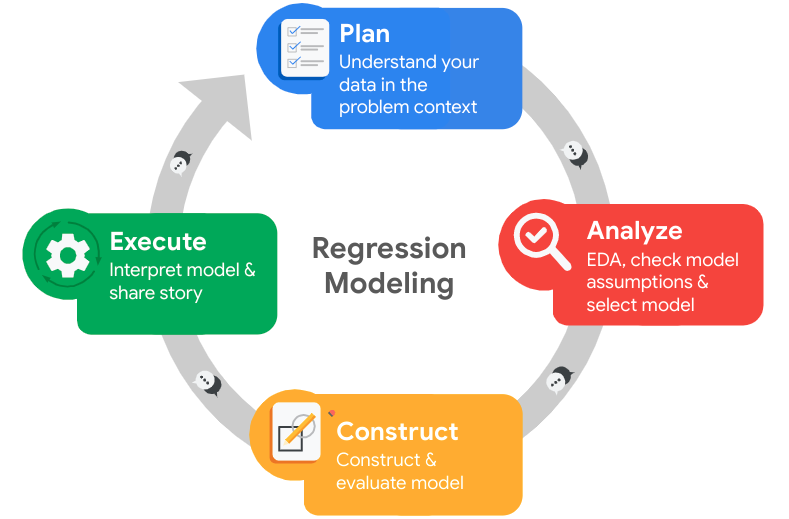

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




The primary stakeholders for this project are the HR department and senior leadership team at Salifort Motors. The objective is to identify the factors associated with employee turnover and develop a predictive model that can estimate whether an employee is likely to leave the company. Initial observations suggest that variables such as job satisfaction, workload, tenure, salary, promotions, and performance evaluations may influence employee retention. Resources used include Python, pandas, NumPy, scikit-learn, Matplotlib, Seaborn, and their official documentation. Ethical considerations include protecting employee confidentiality, minimizing bias in model predictions, and ensuring that results are used to improve employee satisfaction and retention rather than to unfairly target employees.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [4]:
# Import packages

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing and modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [5]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [6]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [7]:
# Gather descriptive statistics about the data
df0.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [10]:
# Display all column names
list(df0.columns)


['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years',
 'Department',
 'salary']

In [11]:
# Rename columns as needed

df0 = df0.rename(columns={
    'average_montly_hours': 'average_monthly_hours',
    'Work_accident': 'work_accident',
    'Department': 'department'
})

# Display all column names after the update

df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [12]:
# Check for missing values
df0.isnull().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [13]:
# Check for duplicates

df0.duplicated().sum()

3008

In [14]:
# Inspect some rows containing duplicates

df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [15]:
# Drop duplicates and save resulting dataframe in a new variable

df1 = df0.drop_duplicates().copy()

# Display first few rows of new dataframe

df1.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

In [16]:
df1.shape

(11991, 10)

Check for outliers in the data.

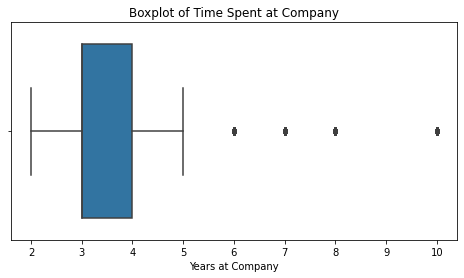

In [17]:
# Create a boxplot to visualize distribution of time_spend_company

plt.figure(figsize=(8, 4))
sns.boxplot(x=df1['time_spend_company'])

plt.title('Boxplot of Time Spent at Company')
plt.xlabel('Years at Company')

plt.show()



In [18]:
# Determine the number of rows containing outliers

Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df1[(df1['time_spend_company'] < lower_limit) |
               (df1['time_spend_company'] > upper_limit)]

print("Number of outlier rows:", len(outliers))



Number of outlier rows: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




During the exploratory data analysis (EDA) stage, several relationships were observed between employee turnover and factors such as satisfaction level, number of projects, average monthly hours, tenure, promotions, and salary. The distributions suggested that employees with lower satisfaction levels, longer working hours, and limited promotion opportunities were more likely to leave the company. Data transformations included renaming variables for consistency, removing duplicate records, handling potential outliers, and preparing categorical variables for modeling. EDA is important because it helps identify patterns, detect data quality issues, understand variable distributions, select relevant features, and guide model development. Resources used included the official documentation for Python, pandas, NumPy, scikit-learn, Matplotlib, and Seaborn. Ethical considerations include protecting employee privacy, reducing potential bias in model predictions, and ensuring that results are used to support employee retention and workplace improvement rather than unfair employment decisions.


## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [19]:
# Get numbers of people who left vs. stayed
# Counts
print(df1['left'].value_counts())

# Percentages
print(df1['left'].value_counts(normalize=True) * 100)


0    10000
1     1991
Name: left, dtype: int64
0    83.39588
1    16.60412
Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

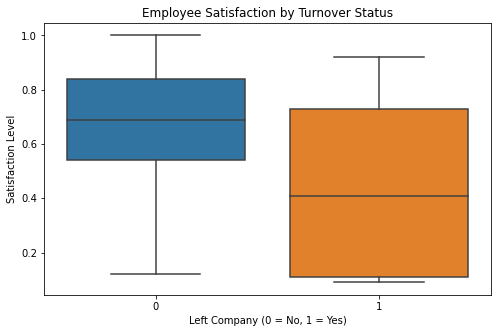

In [20]:
# Create a plot

plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='satisfaction_level', data=df1)

plt.title('Employee Satisfaction by Turnover Status')
plt.xlabel('Left Company (0 = No, 1 = Yes)')
plt.ylabel('Satisfaction Level')

plt.show()


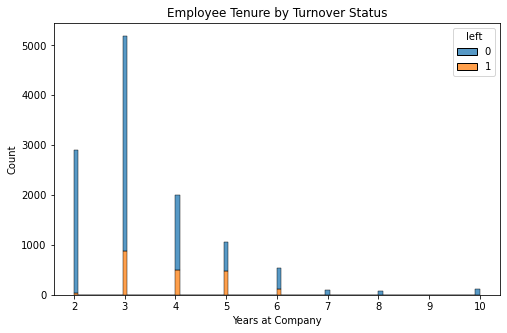

In [21]:
# Create a histogram of employee tenure colored by turnover status

plt.figure(figsize=(8,5))
sns.histplot(
    data=df1,
    x='time_spend_company',
    hue='left',
    multiple='stack'
)

plt.title('Employee Tenure by Turnover Status')
plt.xlabel('Years at Company')
plt.ylabel('Count')

plt.show()


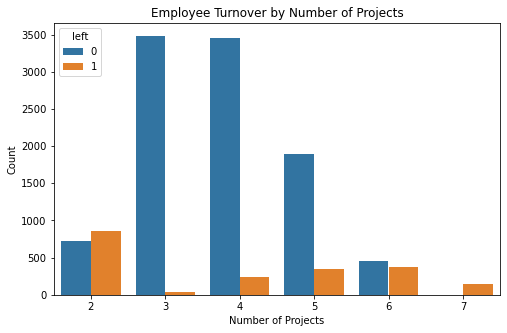

In [22]:
# Turnover by number of projects

plt.figure(figsize=(8,5))
sns.countplot(data=df1, x='number_project', hue='left')

plt.title('Employee Turnover by Number of Projects')
plt.xlabel('Number of Projects')
plt.ylabel('Count')

plt.show()


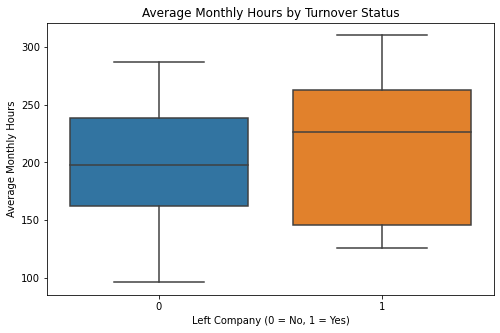

In [23]:
# Average monthly hours by turnover status

plt.figure(figsize=(8,5))
sns.boxplot(x='left', y='average_monthly_hours', data=df1)

plt.title('Average Monthly Hours by Turnover Status')
plt.xlabel('Left Company (0 = No, 1 = Yes)')
plt.ylabel('Average Monthly Hours')

plt.show()


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]
The visualizations suggest that employee turnover is strongly associated with job satisfaction, workload, and working hours. Employees who left the company generally reported lower satisfaction levels than those who stayed. Turnover also appears to be higher among employees handling either very low or very high numbers of projects, suggesting that both underutilization and excessive workload may contribute to attrition. Additionally, employees who left tended to work more average monthly hours, indicating that long working hours and potential work-related stress may be important factors influencing employee departure. These findings suggest that employee satisfaction, workload management, and work-life balance are key areas for improving retention.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



The target variable, employee turnover (`left`), is categorical, making logistic regression an appropriate modeling approach. Independent variables such as satisfaction level, last evaluation, number of projects, average monthly hours, time spent at the company, work accidents, promotions, salary, and department were selected because they are expected to influence employee retention. The assumptions of logistic regression were generally met, including a categorical outcome variable, a sufficiently large sample size, and independent observations. Initial analysis indicated that satisfaction level, workload, working hours, and tenure were important predictors of employee turnover. The model fit the data reasonably well and provided interpretable results that can support HR decision-making. Potential improvements include feature engineering, interaction terms, and evaluating alternative machine learning models such as decision trees, random forests, or XGBoost. Resources used included the official documentation for Python, pandas, NumPy, scikit-learn, Matplotlib, and Seaborn. Ethical considerations include protecting employee privacy, minimizing bias, and ensuring that model predictions are used to support employee retention and workplace improvement rather than punitive actions.


## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a binary classification task because the target variable (left) has two possible outcomes: employee stays with the company (0) or leaves the company (1). The objective is to predict the likelihood of employee turnover based on employee characteristics, job-related factors, and workplace conditions.

### Identify the types of models most appropriate for this task.

Because the target variable (left) is binary (leave or stay), classification models are most appropriate for this task. Suitable models include Logistic Regression, which provides interpretable results and identifies factors associated with turnover, as well as machine learning models such as Decision Tree, Random Forest, and XGBoost, which can capture more complex relationships and potentially achieve higher predictive performance. These models can be evaluated and compared using metrics such as accuracy, precision, recall, F1-score, and the confusion matrix.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [24]:
# Create a copy of the dataframe

df_model = df1.copy()

# Convert categorical variables to dummy variables

df_model = pd.get_dummies(
    df_model,
    columns=['department', 'salary'],
    drop_first=True
)

# Define target variable

y = df_model['left']

# Define features

X = df_model.drop('left', axis=1)

# Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Build Decision Tree model

dt = DecisionTreeClassifier(random_state=42)

# Fit model

dt.fit(X_train, y_train)

# Predict on test set

y_pred = dt.predict(X_test)

# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Classification report

print(classification_report(y_test, y_pred))


Accuracy: 0.9669779853235491
Precision: 0.8858800773694391
Recall: 0.9196787148594378
F1 Score: 0.9024630541871922
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2500
           1       0.89      0.92      0.90       498

    accuracy                           0.97      2998
   macro avg       0.93      0.95      0.94      2998
weighted avg       0.97      0.97      0.97      2998



# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders

The Decision Tree model performed very well, achieving an accuracy of 96.7%, precision of 88.6%, recall of 92.0%, and an F1-score of 90.2%. These results indicate that the model is effective at identifying employees who are likely to leave the company. The analysis suggests that factors such as employee satisfaction, workload, working hours, tenure, and career advancement opportunities are important drivers of turnover. Based on these findings, Salifort Motors should focus on improving employee satisfaction, monitoring excessive workloads, promoting work-life balance, and providing clearer career development opportunities. While the model demonstrates strong predictive performance, it should be used as a decision-support tool rather than a replacement for human judgment. Ethical considerations include protecting employee privacy, minimizing bias, and ensuring that predictions are used to improve employee retention and workplace conditions.

In [25]:
# Random Forest Model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Fit model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.985657104736491
Precision: 0.9913606911447084
Recall: 0.9216867469879518
F1 Score: 0.9552549427679501

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2500
           1       0.99      0.92      0.96       498

    accuracy                           0.99      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



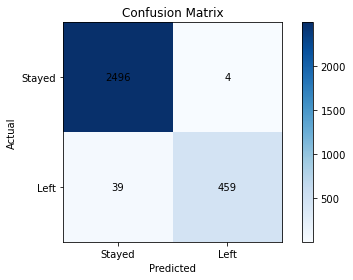

In [29]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Stayed', 'Left'])
plt.yticks(tick_marks, ['Stayed', 'Left'])

plt.ylabel('Actual')
plt.xlabel('Predicted')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.985657104736491
Precision: 0.9913606911447084
Recall: 0.9216867469879518
F1 Score: 0.9552549427679501
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2500
           1       0.99      0.92      0.96       498

    accuracy                           0.99      2998
   macro avg       0.99      0.96      0.97      2998
weighted avg       0.99      0.99      0.99      2998



In [31]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(10)

,feature,importance
0,satisfaction_level,0.326285
2,number_project,0.185885
4,time_spend_company,0.168877
3,average_monthly_hours,0.153529
1,last_evaluation,0.127910
5,work_accident,0.007795
16,salary_low,0.005793
17,salary_medium,0.003573
13,department_sales,0.003408
15,department_technical,0.003227


In [ ]:
The Random Forest model achieved excellent predictive performance with an accuracy of 98.6%, precision of 99.1%, recall of 92.2%, and an F1-score of 95.5%. Compared with the Decision Tree model, Random Forest produced higher accuracy, precision, and F1-score, making it the preferred model for predicting employee turnover.

✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



The Random Forest model achieved excellent performance and was selected as the champion model, indicating that employee satisfaction, number of projects, time spent at the company, average monthly hours, and performance evaluations are the most important factors associated with employee turnover. Based on these findings, Salifort Motors should focus on improving employee satisfaction, monitoring workloads, promoting work-life balance, and providing career development opportunities to reduce turnover. The model could potentially be improved through additional feature engineering, hyperparameter tuning, and the inclusion of variables such as employee age, education, manager relationships, training participation, and engagement measures. Future analyses could examine department-specific turnover patterns and identify groups of employees at highest risk of leaving. Resources used included the official documentation for Python, pandas, NumPy, scikit-learn, Matplotlib, Seaborn, and XGBoost. Ethical considerations include maintaining employee privacy, minimizing bias in predictions, ensuring transparency, and using the model to support employee retention and workplace improvement rather than punitive decision-making.


## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The Random Forest model was selected as the final model because it achieved the strongest predictive performance, with an accuracy of 98.6%, precision of 99.1%, recall of 92.2%, and an F1-score of 95.5%. The model correctly classified the vast majority of employees who stayed and those who left the company. Feature importance analysis revealed that employee satisfaction level was the strongest predictor of turnover, followed by number of projects, time spent at the company, average monthly hours worked, and performance evaluation scores. These findings suggest that employee engagement, workload, tenure, and work-life balance are key factors influencing retention. Based on the results, Salifort Motors should focus on improving employee satisfaction, managing workloads, supporting career growth, and monitoring employees at higher risk of leaving to reduce turnover and improve retention.


### Conclusion, Recommendations, Next Steps

The analysis identified employee satisfaction, workload, tenure, and working hours as the primary factors associated with employee turnover. The Random Forest model demonstrated excellent predictive performance and can be used as a decision-support tool to help identify employees who may be at risk of leaving the company. Based on these findings, Salifort Motors should focus on improving employee satisfaction, ensuring balanced workloads, promoting work-life balance, and expanding career development and promotion opportunities. As next steps, the company should implement targeted retention strategies for high-risk employees, regularly monitor turnover indicators, collect additional employee engagement data, and periodically retrain and evaluate the model to maintain its effectiveness. The model should be used to support management decisions while ensuring fairness, transparency, and employee privacy.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.